## Setup

**Test date: 1.5.2026**

**CPU**: AMD Ryzen 9 7950X 16-Core Processor

**RAM**: 128GB DDR5 G-Skill Trident Z5

**GPU**: NVIDIA RTX 4090

Running on **Ollama v0.21.0** and **Open WebUI v0.9.2** as the interface.

**Gemma4:31b** was tasked with generating a **couch** using the **SPOMSO** package. The model was provided with the [spomso_sdf_guide](./guides/spomso_sdf_guide.md) file and the following prompt:

*Read through the attached .md file. It contains a guide how to use the Python package SPOMSO. I want you to design a couch using this Python package. As the output I want some code that I would run and it would output the point cloud of the object and some figures. Make sure that the resulting plots show true proportions of the object. Everything else I leave up to you. Good luck and if you have any questions feel free to ask.*

## Response:

To design a couch using the SPOMSO library, we can combine several 3D primitives—specifically `Box` and `Cylinder`—and apply rounding to give the couch a soft, upholstered appearance [1].

Below is the complete Python code to generate the couch, extract its surface point cloud, and visualize the results. I have used a `UNION` operation to merge the components and ensured that the `extent` in the plotting functions reflects the physical dimensions of the grid to maintain true proportions [1].

Surface point cloud saved with 161700 points.


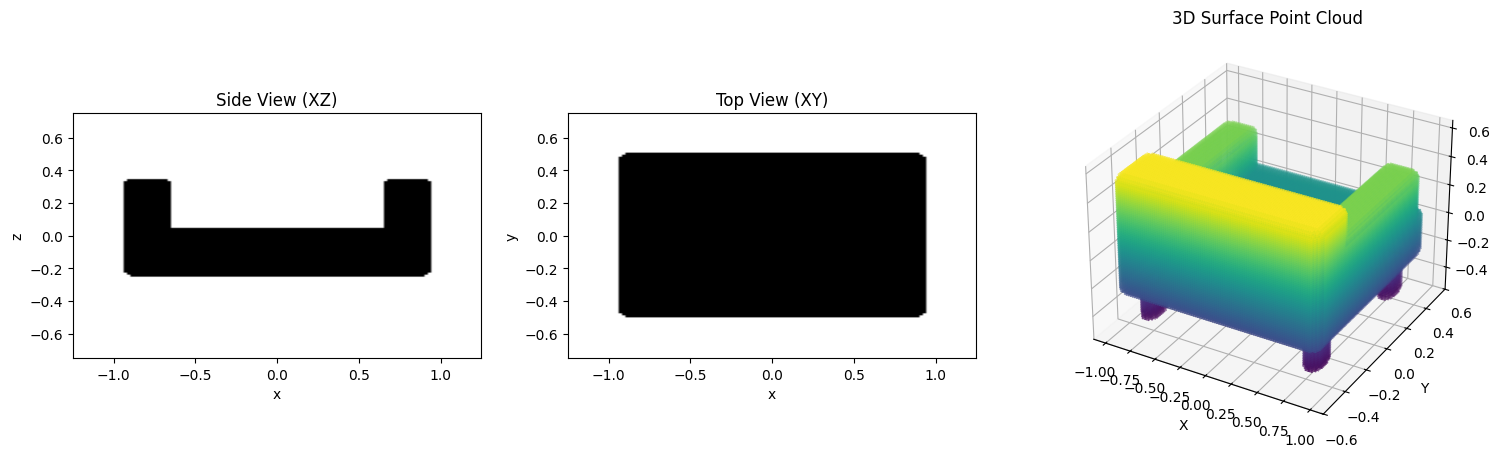

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from spomso.cores.helper_functions import generate_grid, smarter_reshape
from spomso.cores.post_processing import hard_binarization
from spomso.cores.geom_3d import Box, Cylinder
from spomso.cores.combine import CombineGeometry

# 1. Grid Setup [1]
# Physical extent (x, y, z) and resolution
CO_SIZE = (2.5, 1.5, 1.5)
CO_RESOLUTION = (120, 120, 120)
coor, co_res_new = generate_grid(CO_SIZE, CO_RESOLUTION)

# 2. Designing the Couch Components [1]
# Base / Seat
seat = Box(1.8, 0.9, 0.2)
seat.rounding(0.05)
seat.move((0.0, 0.0, -0.1))

# Backrest
backrest = Box(1.8, 0.15, 0.6)
backrest.rounding(0.05)
backrest.move((0.0, -0.375, 0.2)) # Positioned at the back of the seat

# Armrests (Left and Right)
arm_l = Box(0.2, 0.8, 0.4)
arm_l.rounding(0.05)
arm_l.move((-0.8, 0.0, 0.1))

arm_r = Box(0.2, 0.8, 0.4)
arm_r.rounding(0.05)
arm_r.move((0.8, 0.0, 0.1))

# Legs (4 Cylinders)
leg_positions = [
    (0.8, 0.35, -0.3), (0.8, -0.35, -0.3),
    (-0.8, 0.35, -0.3), (-0.8, -0.35, -0.3)
]
legs = []
for pos in leg_positions:
    leg = Cylinder(0.05, 0.3)
    leg.rounding(0.01)
    leg.move(pos)
    legs.append(leg)

# 3. Combine all parts into one geometry [1]
couch = CombineGeometry("UNION").combine(
    seat, backrest, arm_l, arm_r, *legs
)

# Generate the SDF values [1]
sdf_values = couch.create(coor)

# 4. Point Cloud Extraction [1]
dx = CO_SIZE[0] / CO_RESOLUTION[0]
surface_mask = np.abs(sdf_values) < dx * 1.5
surface_pts = coor[:, surface_mask].T
np.save("couch_surface.npy", surface_pts)
print(f"Surface point cloud saved with {surface_pts.shape[0]} points.")

# 5. Visualization [1]
# Binarization for cross-sections
binary_flat = hard_binarization(sdf_values, 0)
binary_3d = smarter_reshape(binary_flat, CO_RESOLUTION)

fig = plt.figure(figsize=(15, 5))

# Side View (XZ Plane) - True proportions via 'extent' [1]
ax1 = fig.add_subplot(131)
ax1.imshow(
    binary_3d[:, CO_RESOLUTION[1]//2, :].T,
    cmap="Greys", origin="lower",
    extent=(-CO_SIZE[0]/2, CO_SIZE[0]/2, -CO_SIZE[2]/2, CO_SIZE[2]/2)
)
ax1.set_title("Side View (XZ)")
ax1.set_xlabel("x"); ax1.set_ylabel("z")

# Top View (XY Plane) - True proportions via 'extent' [1]
ax2 = fig.add_subplot(132)
ax2.imshow(
    binary_3d[:, :, CO_RESOLUTION[2]//2].T,
    cmap="Greys", origin="lower",
    extent=(-CO_SIZE[0]/2, CO_SIZE[0]/2, -CO_SIZE[1]/2, CO_SIZE[1]/2)
)
ax2.set_title("Top View (XY)")
ax2.set_xlabel("x"); ax2.set_ylabel("y")

# 3D Point Cloud View [1]
ax3 = fig.add_subplot(133, projection="3d")
ax3.scatter(surface_pts[:, 0], surface_pts[:, 1], surface_pts[:, 2],
            c=surface_pts[:, 2], cmap="viridis", s=0.2)
ax3.set_title("3D Surface Point Cloud")
ax3.set_xlabel("X"); ax3.set_ylabel("Y"); ax3.set_zlabel("Z")

plt.tight_layout()
plt.show()

### Design Choices & Technical Details:
- **Proportions:** I used a base of $1.8 \times 0.9 \times 0.2$ units to ensure a realistic couch-to-leg ratio. By setting the `extent` parameter in `imshow` using `CO_SIZE`, the figures display the object's true physical dimensions rather than pixel indices [1].
- **Rounding:** I applied `.rounding(0.05)` to the main cushions and armrests. According to the guide, modifications are applied before Euclidean transformations, so rounding is performed before moving the pieces into place [1].
- **Combining:** The `CombineGeometry("UNION")` operation was used to merge the disparate components into a single `GenericGeometry` object, which allows for the evaluation of the final SDF over the coordinate grid [1].
- **Surface Extraction:** Following the guide's methodology, the point cloud was extracted by thresholding the SDF values within a small range of zero ($\pm 1.5 \times \text{voxel step}$) [1].

**End response**

**Approximate time:** 2m 42s

## Validation

The entire **object** can be visualized with the code below:

In [ ]:
import plotly.graph_objects as go
fig = go.Figure(data=go.Volume(
    x=coor[0],
    y=coor[1],
    z=coor[2],
    value=binary_flat,
    isomin=0.9,
    isomax=1,
    opacity=1,
    surface_count=2,
))
fig.show()